Random Forest    MAE=  192.22  RMSE=  397.82  R2=0.5018
XGBoost          MAE=  191.68  RMSE=  407.89  R2=0.4763

            Model         MAE        RMSE        R2
0  Random Forest  192.219820  397.818749  0.501816
1        XGBoost  191.677283  407.890442  0.476271


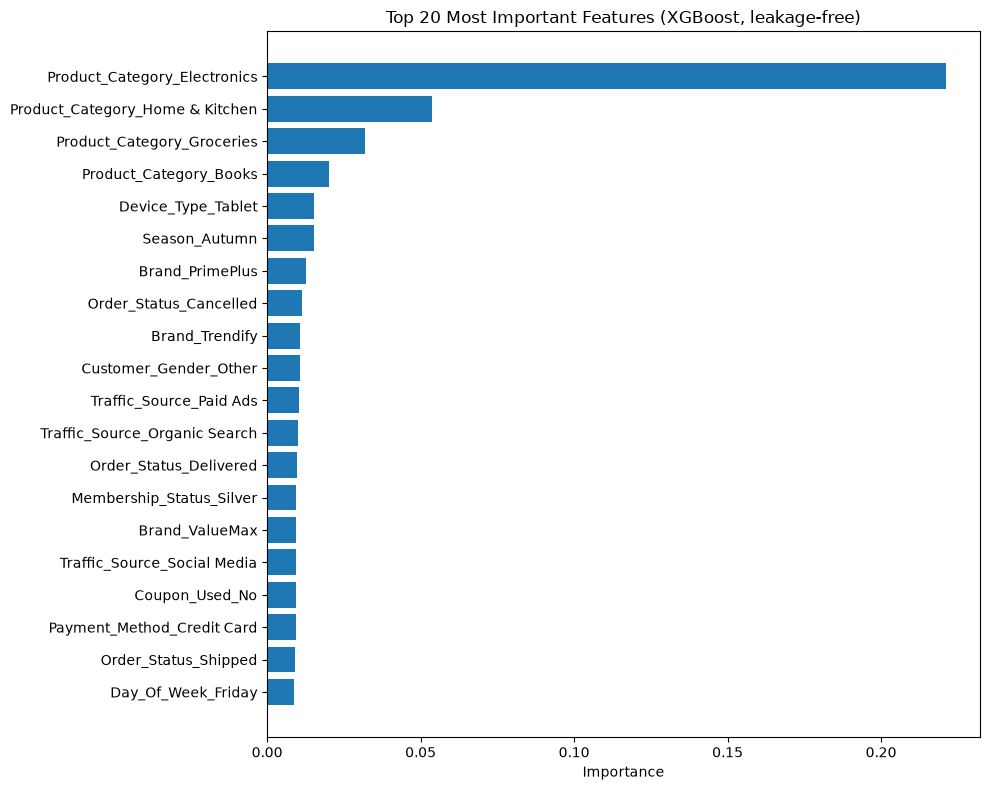

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("../dataset/original_dataset/ecommerce_orders_dataset.csv")

TARGET = "Order_Amount"

# Columns that are exact arithmetic components of Order_Amount,
# or derived post-hoc from it — must NOT be features.
LEAKAGE_COLS = [
    "Unit_Price", "Quantity", "Discount_Percent", "Discount_Amount",
    "Shipping_Cost", "Tax_Amount", "Profit_Amount", "Profit_Margin_Percent",
    "High_Value_Order", "Customer_Lifetime_Value",
]
ID_COLS = ["Order_ID", "Customer_ID", "Product_ID", "Order_Date"]

X = df.drop(columns=LEAKAGE_COLS + ID_COLS + [TARGET])
y = df[TARGET]

# ---------------------------------------------------------
# 2. Column types for preprocessing
# ---------------------------------------------------------
categorical_cols = [
    "Customer_Gender", "Country", "City", "Customer_Segment", "Product_Category",
    "Product_Subcategory", "Brand", "Coupon_Used", "Payment_Method", "Device_Type",
    "Traffic_Source", "Membership_Status", "Shipping_Method", "Warehouse_Region",
    "Order_Status", "Returned", "Day_Of_Week", "Season", "Holiday_Season",
]
numeric_cols = [
    "Customer_Age", "Delivery_Days", "Review_Rating", "Year", "Month", "Day", "Quarter",
]

assert set(categorical_cols + numeric_cols) == set(X.columns), \
    "Column list mismatch — check for typos or missing columns"

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

# ---------------------------------------------------------
# 3. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 4. Models
# ---------------------------------------------------------
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

# ---------------------------------------------------------
# 5. Fit + evaluate
# ---------------------------------------------------------
def evaluate(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name:15s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate(rf_model, "Random Forest"))
results.append(evaluate(xgb_model, "XGBoost"))

results_df = pd.DataFrame(results)
print("\n", results_df)

# ---------------------------------------------------------
# 6. Feature importance (from XGBoost, usually the stronger model)
# ---------------------------------------------------------
def plot_importance(fitted_pipeline, title, top_n=20):
    ohe_cols = fitted_pipeline.named_steps["preprocessor"] \
        .named_transformers_["cat"].get_feature_names_out(categorical_cols)
    all_feature_names = numeric_cols + list(ohe_cols)

    importances = fitted_pipeline.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_importance(xgb_model, "Top 20 Most Important Features (XGBoost, leakage-free)")